# Block-exact RTRL 与 reverse BPTT scaling

这个 notebook **只读取** Python benchmark runner 生成的 CSV，不运行仿真或编译。Benchmark 使用 A100、x64、`dt=0.025 ms`，每个配置/方法在独立进程中编译，并报告十次同步 steady execution 的中位数。

状态按 `(seed, batch, state, CV)` 组织；每个 seed 有独立的 `3*C` 参数并对同一 batch 求梯度。RTRL 在 seed 轴上使用 block-exact `vmap`，不保存跨 seed 恒零 sensitivity。

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import NullLocator
import numpy as np
import pandas as pd

from braincell.vis import PUBLICATION_RC_PARAMS

get_ipython().run_line_magic("matplotlib", "inline")
PAPER_RC = {
    **PUBLICATION_RC_PARAMS,
    "font.size": 8.5,
    "axes.titlesize": 9.0,
    "axes.labelsize": 8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
    "axes.linewidth": 0.8,
    "lines.linewidth": 1.45,
    "lines.markersize": 4.2,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "legend.frameon": False,
    "figure.dpi": 150.0,
    "savefig.dpi": 300.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
}
plt.rcParams.update(PAPER_RC)

root = next(
    path
    for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "pyproject.toml").exists() and (path / "braincell").is_dir()
)
artifact_root = root / "benchmarks/performance/optim_gradient_scaling/artifacts/rtrl_bptt_scaling"
figure_root = artifact_root / "figures"
figure_root.mkdir(parents=True, exist_ok=True)
factorial_candidates = sorted(artifact_root.glob("mechanism_factorial_*"), key=lambda path: path.stat().st_mtime)
controlled_default = artifact_root / "controlled_complexity_a100"
controlled_candidates = sorted(
    (path for path in artifact_root.glob("controlled_complexity_*") if "incomplete" not in path.name),
    key=lambda path: path.stat().st_mtime,
)
configured = os.environ.get("RTRL_BENCHMARK_DIR")
if configured:
    result_dirs = [Path(configured).expanduser().resolve()]
else:
    full_candidates = sorted(artifact_root.glob("full_*"), key=lambda path: path.stat().st_mtime)
    pilot_candidates = sorted(artifact_root.glob("pilot_*"), key=lambda path: path.stat().st_mtime)
    large_candidates = sorted(artifact_root.glob("large_cv_*"), key=lambda path: path.stat().st_mtime)
    ordinary_candidates = sorted(artifact_root.glob("backsub_ordinary_*"), key=lambda path: path.stat().st_mtime)
    primary = full_candidates[-1:] or pilot_candidates[-1:]
    result_dirs = primary + large_candidates[-1:] + ordinary_candidates[-1:]
    if not result_dirs:
        raise FileNotFoundError("Run optim_gradient_scaling/benchmark.py first.")

frames = []
for directory in result_dirs:
    frame = pd.read_csv(directory / "results.csv")
    frame["result_directory"] = str(directory)
    if "backsub" not in frame:
        frame["backsub"] = "recursive"
    else:
        frame["backsub"] = frame.backsub.fillna("recursive")
    frames.append(frame)
results = pd.concat(frames, ignore_index=True).drop_duplicates(["config_id", "method", "backsub"], keep="last")
all_ok = results[results.status == "ok"].copy()
ok = all_ok[all_ok.backsub == "recursive"].copy()
factorial_result_dir = factorial_candidates[-1] if factorial_candidates else None
if factorial_result_dir is not None:
    factorial_results = pd.read_csv(factorial_result_dir / "results.csv")
    factorial_ok = factorial_results[
        (factorial_results.status == "ok") & (factorial_results.backsub == "recursive")
    ].copy()
else:
    factorial_ok = pd.DataFrame()
controlled_configured = os.environ.get("RTRL_CONTROLLED_BENCHMARK_DIR")
controlled_result_dir = (
    Path(controlled_configured).expanduser().resolve()
    if controlled_configured
    else (
        controlled_default
        if controlled_default.exists()
        else (controlled_candidates[-1] if controlled_candidates else None)
    )
)
if controlled_result_dir is not None and (controlled_result_dir / "results.csv").exists():
    controlled_results = pd.read_csv(controlled_result_dir / "results.csv")
    controlled_ok = controlled_results[
        (controlled_results.status == "ok") & (controlled_results.backsub == "recursive")
    ].copy()
else:
    controlled_ok = pd.DataFrame()
print("result directories:")
for directory in result_dirs:
    print("  ", directory)
print("successful trials:", len(all_ok), "/", len(results))
print("methods:", tuple(all_ok.method.unique()))
print("backsub modes:", tuple(all_ok.backsub.unique()))
print("factorial trials:", len(factorial_ok))
print("controlled trials:", len(controlled_ok))

result directories:
   examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/full_block_exact
   examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/large_cv_block_exact
   examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/backsub_ordinary_block_exact
successful trials: 52 / 52
methods: ('bptt', 'rtrl')
backsub modes: ('recursive', 'ordinary')
factorial trials: 60
controlled trials: 132


## 结果总表

`temporary` 是 XLA static buffer analysis；`GPU peak` 是独立 worker 进程的 NVML allocation peak。后者包含 CUDA/JAX runtime 与 allocator 保留内存，适合看大规模增长，不等同于单个张量尺寸。

In [2]:
summary = ok[
    [
        "config_id",
        "method",
        "compile_seconds",
        "steady_median_seconds",
        "temporary_bytes",
        "rtrl_carry_bytes",
        "gpu_peak_steady_bytes",
        "bptt_over_rtrl_time",
        "gradient_max_rel_error",
    ]
].sort_values(["config_id", "method"])
formatted = summary.copy()
formatted["compile_seconds"] = formatted.compile_seconds.map(lambda value: f"{value:.3f}")
formatted["steady_median_seconds"] = formatted.steady_median_seconds.map(lambda value: f"{value:.4f}")
formatted["temporary_bytes"] = formatted.temporary_bytes.map(lambda value: f"{value / 2**20:.2f} MiB")
formatted["rtrl_carry_bytes"] = formatted.rtrl_carry_bytes.map(
    lambda value: "-" if pd.isna(value) else f"{value / 2**20:.3f} MiB"
)
formatted["gpu_peak_steady_bytes"] = formatted.gpu_peak_steady_bytes.map(lambda value: f"{value / 2**20:.1f} MiB")
formatted["bptt_over_rtrl_time"] = formatted.bptt_over_rtrl_time.map(lambda value: f"{value:.2f}x")
formatted["gradient_max_rel_error"] = formatted.gradient_max_rel_error.map(lambda value: f"{value:.2e}")
display(formatted)

,config_id,method,compile_seconds,steady_median_seconds,temporary_bytes,rtrl_carry_bytes,gpu_peak_steady_bytes,bptt_over_rtrl_time,gradient_max_rel_error
36,c13_t40_b16_s16,bptt,236.262,1.9433,3602.36 MiB,-,4610.0 MiB,2.67x,7.94e-09
37,c13_t40_b16_s16,rtrl,46.800,0.7266,13.04 MiB,6.360 MiB,476.0 MiB,2.67x,7.94e-09
38,c17_t40_b16_s16,bptt,429.526,2.8303,5016.04 MiB,-,8712.0 MiB,2.85x,2.91e-11
39,c17_t40_b16_s16,rtrl,64.171,0.9946,21.80 MiB,10.857 MiB,484.0 MiB,2.85x,2.91e-11
0,c1_t40_b16_s16,bptt,4.664,0.3214,262.74 MiB,-,976.0 MiB,3.91x,1.50e-14
1,c1_t40_b16_s16,rtrl,3.293,0.0822,0.28 MiB,0.041 MiB,464.0 MiB,3.91x,1.50e-14
40,c25_t40_b16_s16,bptt,163.137,9.5165,7363.25 MiB,-,8760.0 MiB,6.18x,3.95e-10
41,c25_t40_b16_s16,rtrl,95.444,1.5393,46.14 MiB,23.438 MiB,560.0 MiB,6.18x,3.95e-10
42,c33_t40_b16_s16,bptt,258.859,13.7799,10344.75 MiB,-,16986.0 MiB,5.23x,5.37e-09
43,c33_t40_b16_s16,rtrl,133.466,2.6343,75.03 MiB,40.799 MiB,628.0 MiB,5.23x,5.37e-09


In [3]:
BASELINE = {"n_cv": 5, "duration_ms": 40.0, "batch_size": 16, "n_seed": 16}
AXES = (
    ("n_cv", "CV count"),
    ("duration_ms", "duration (ms)"),
    ("batch_size", "batch size"),
    ("n_seed", "independent seeds"),
)
FULL_WIDTH_IN = 7.1
COLORS = {"bptt": "#D55E00", "rtrl": "#0072B2", "carry": "#009E73"}
LABELS = {"bptt": "reverse BPTT", "rtrl": "block-exact RTRL"}
MARKERS = {"bptt": "s", "rtrl": "o", "carry": "^"}
PANEL_LABELS = tuple("abcdefghijklmnopqrstuvwxyz")


def axis_slice(axis):
    selected = ok.copy()
    for name, value in BASELINE.items():
        if name != axis:
            selected = selected[selected[name] == value]
    return selected.sort_values(axis)


def axis_coordinates(rows, axis):
    if axis == "n_cv":
        return 4 * rows.n_cv
    return rows[axis]


def n_x_to_n_theta(n_x):
    return 3 * np.asarray(n_x) / 4


def n_theta_to_n_x(n_theta):
    return 4 * np.asarray(n_theta) / 3


def model_size_ticks(rows):
    ticks = rows.drop_duplicates("n_cv").sort_values("n_cv")
    preferred = ticks[ticks.n_cv.isin([1, 5, 9, 17, 33])]
    return preferred if len(preferred) >= 3 else ticks


def add_model_size_axis(panel, rows, *, label=True):
    ticks = model_size_ticks(rows)
    panel.set_xticks(4 * ticks.n_cv, (4 * ticks.n_cv).astype(str))
    panel.xaxis.set_minor_locator(NullLocator())
    secondary = panel.secondary_xaxis("top", functions=(n_x_to_n_theta, n_theta_to_n_x))
    secondary.spines["top"].set_visible(True)
    secondary.set_xticks(3 * ticks.n_cv, (3 * ticks.n_cv).astype(str))
    secondary.xaxis.set_minor_locator(NullLocator())
    if label:
        secondary.set_xlabel(r"$N_\theta = 3C$")
    return secondary


def style_panel(panel, *, log_y=False):
    if log_y:
        panel.set_yscale("log")
    panel.grid(axis="y", which="major", color="#D9D9D9", linewidth=0.55)
    panel.set_axisbelow(True)
    panel.tick_params(length=3.0, width=0.7)


def add_panel_labels(axes):
    for label, panel in zip(PANEL_LABELS, np.asarray(axes).flat):
        panel.text(-0.16, 1.04, label, transform=panel.transAxes, fontweight="bold", va="bottom")


def save_figure(figure, stem):
    outputs = []
    for suffix in ("pdf", "png"):
        path = figure_root / f"{stem}.{suffix}"
        figure.savefig(path, dpi=300, bbox_inches="tight")
        outputs.append(path)
    return tuple(outputs)


def method_handles(*, include_carry=False):
    handles = [
        Line2D([], [], color=COLORS[method], marker=MARKERS[method], label=LABELS[method])
        for method in ("bptt", "rtrl")
    ]
    if include_carry:
        handles.append(
            Line2D([], [], color=COLORS["carry"], marker=MARKERS["carry"], linestyle=":", label="RTRL logical carry")
        )
    return handles

## Figure 1 — Controlled-axis scaling

每列只改变一个维度，其余固定为 `C5/T40/B16/S16`。模型规模列底轴为单条轨迹状态数 `N_x=4C`，顶轴为共享参数数 `N_θ=3C`。内存行同时展示 XLA temporary 与 RTRL logical carry；它们是不同语义的字节量，不能相加。

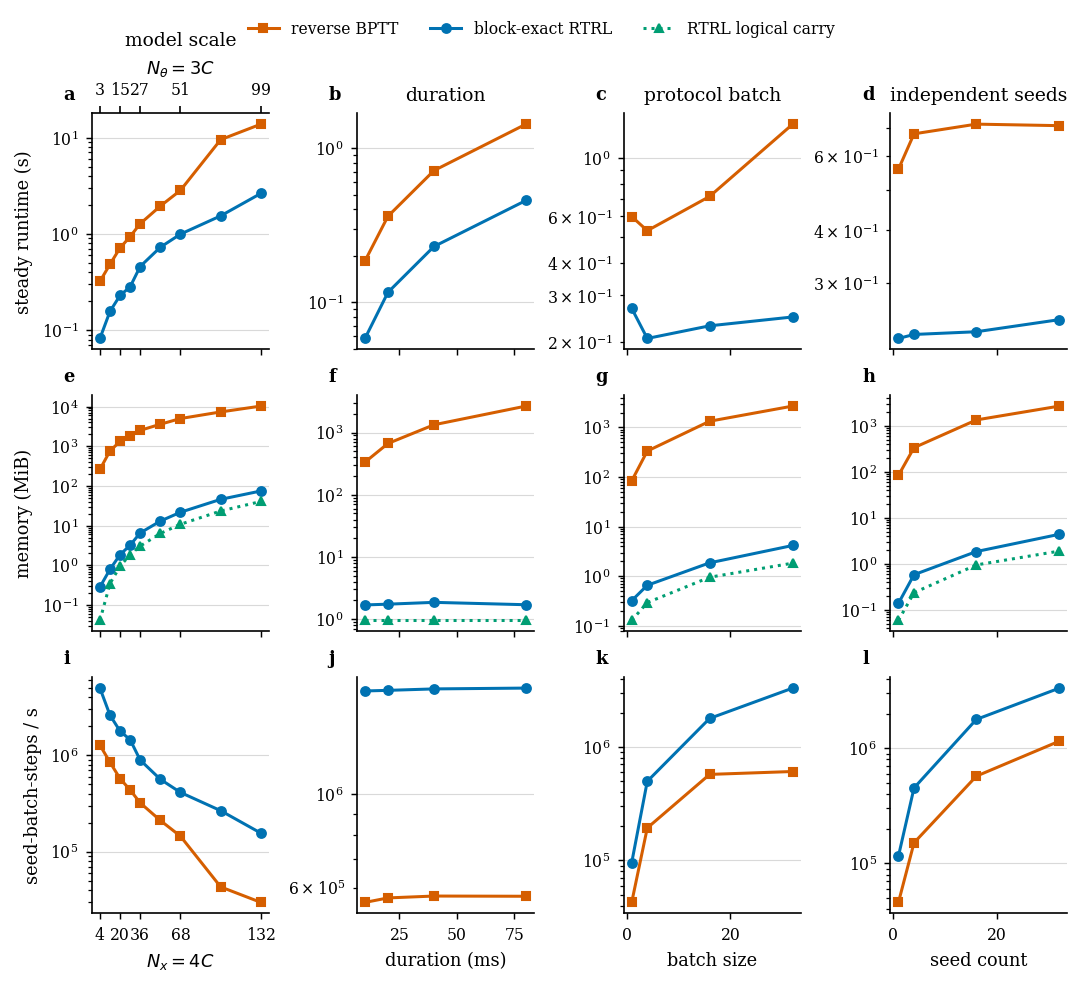

saved:
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/fig01_scaling_overview.pdf
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/fig01_scaling_overview.png


In [4]:
overview_metrics = (
    ("steady_median_seconds", 1.0, "steady runtime (s)"),
    ("temporary_bytes", 2**20, "memory (MiB)"),
    ("throughput_seed_batch_steps_per_second", 1.0, "seed-batch-steps / s"),
)
column_titles = ("model scale", "duration", "protocol batch", "independent seeds")
bottom_labels = (r"$N_x = 4C$", "duration (ms)", "batch size", "seed count")
fig, axes = plt.subplots(3, 4, figsize=(FULL_WIDTH_IN, 6.35), constrained_layout=True)
for column, ((axis, _xlabel), title, bottom_label) in enumerate(zip(AXES, column_titles, bottom_labels)):
    selected = axis_slice(axis)
    for row_index, (metric, scale, ylabel) in enumerate(overview_metrics):
        panel = axes[row_index, column]
        for method in ("bptt", "rtrl"):
            rows = selected[selected.method == method].sort_values(axis)
            panel.plot(
                axis_coordinates(rows, axis),
                rows[metric] / scale,
                color=COLORS[method],
                marker=MARKERS[method],
            )
        if metric == "temporary_bytes":
            carry = selected[selected.method == "rtrl"].sort_values(axis)
            panel.plot(
                axis_coordinates(carry, axis),
                carry.rtrl_carry_bytes / scale,
                color=COLORS["carry"],
                marker=MARKERS["carry"],
                linestyle=":",
            )
        style_panel(panel, log_y=True)
        if column == 0:
            panel.set_ylabel(ylabel)
        if row_index == 0:
            panel.set_title(title)
        if row_index == len(overview_metrics) - 1:
            panel.set_xlabel(bottom_label)
        else:
            panel.tick_params(labelbottom=False)
    if axis == "n_cv":
        add_model_size_axis(axes[0, column], selected, label=True)
        for row_index in (1, 2):
            ticks = model_size_ticks(selected)
            axes[row_index, column].set_xticks(4 * ticks.n_cv, (4 * ticks.n_cv).astype(str))
add_panel_labels(axes)
fig.legend(handles=method_handles(include_carry=True), loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02))
figure1_paths = save_figure(fig, "fig01_scaling_overview")
plt.show()
print("saved:", *(str(path) for path in figure1_paths), sep="\n  ")

In [5]:
batch_profile_root = artifact_root.parent / "rtrl_bptt_batch_profile"
core_profiles = {
    "B16/S16": batch_profile_root / "core/b16_s16.json",
    "B32/S16": batch_profile_root / "core/b32_s16.json",
    "B16/S32": batch_profile_root / "core/b16_s32.json",
    "B32/S32": batch_profile_root / "core/b32_s32.json",
}


def load_profile(path):
    payload = json.loads(path.read_text())
    steady = np.asarray([row["wall_time_s"] for row in payload["phases"] if row["phase"] == "steady_run"])
    return payload, {
        "median_seconds": np.median(steady),
        "p90_seconds": np.quantile(steady, 0.9),
        "temporary_gib": payload["metadata"]["memory_analysis"]["temporary_bytes"] / 2**30,
    }


batch_profile_available = all(path.exists() for path in core_profiles.values())
if batch_profile_available:
    core_rows = []
    core_payloads = {}
    for label, path in core_profiles.items():
        payload, stats = load_profile(path)
        core_payloads[label] = payload
        core_rows.append({"shape": label, **stats})
    core_profile = pd.DataFrame(core_rows)

    baseline_gradient = np.asarray(core_payloads["B32/S16"]["materialized"]["gradient"])
    padding_rows = []
    for path in sorted((batch_profile_root / "padding").glob("*.json")):
        payload, stats = load_profile(path)
        gradient = np.asarray(payload["materialized"]["gradient"])
        padding_rows.append(
            {
                "execution_seed_count": payload["metadata"]["execution_seed_count"],
                **stats,
                "gradient_relative_l2": np.linalg.norm(gradient - baseline_gradient)
                / np.linalg.norm(baseline_gradient),
            }
        )
    baseline_stats = core_profile[core_profile["shape"] == "B32/S16"].iloc[0]
    padding_rows.append(
        {
            "execution_seed_count": 16,
            "median_seconds": baseline_stats.median_seconds,
            "p90_seconds": baseline_stats.p90_seconds,
            "temporary_gib": baseline_stats.temporary_gib,
            "gradient_relative_l2": 0.0,
        }
    )
    padding_profile = (
        pd.DataFrame(padding_rows).drop_duplicates("execution_seed_count").sort_values("execution_seed_count")
    )

    nsys_rows = []
    for execution_seed_count in (16, 28):
        path = batch_profile_root / "nsys" / f"b32_s16_exec{execution_seed_count}_cuda_api_sum.csv"
        if not path.exists():
            continue
        api = pd.read_csv(path)
        graph = api[api.Name == "cuGraphLaunch"].iloc[0]
        nsys_rows.append(
            {
                "execution_seed_count": execution_seed_count,
                "cuGraphLaunch_calls": int(graph["Num Calls"]),
                "cuGraphLaunch_total_ms": graph["Total Time (ns)"] / 1e6,
                "cuGraphLaunch_mean_us": graph["Avg (ns)"] / 1e3,
            }
        )
    nsys_profile = pd.DataFrame(nsys_rows)

else:
    core_profile = padding_profile = nsys_profile = None

In [6]:
# Memory curves are consolidated into Figures 1 and 2.

In [7]:
baseline_system = ok.copy()
for name, value in BASELINE.items():
    baseline_system = baseline_system[baseline_system[name] == value]
baseline_system = baseline_system.set_index("method")
system_rows = []
for method in ("bptt", "rtrl"):
    rows = ok[ok.method == method]
    base = baseline_system.loc[method]
    system_rows.append(
        {
            "method": LABELS[method],
            "GPU util baseline (%)": base.gpu_util_steady_median_percent,
            "GPU util range (%)": f"{rows.gpu_util_steady_median_percent.min():.0f}–{rows.gpu_util_steady_median_percent.max():.0f}",
            "memory-controller baseline (%)": base.gpu_memory_util_steady_median_percent,
            "memory-controller range (%)": f"{rows.gpu_memory_util_steady_median_percent.min():.0f}–{rows.gpu_memory_util_steady_median_percent.max():.0f}",
            "power baseline (W)": base.gpu_power_steady_median_watts,
            "power range (W)": f"{rows.gpu_power_steady_median_watts.min():.0f}–{rows.gpu_power_steady_median_watts.max():.0f}",
        }
    )
system_summary = pd.DataFrame(system_rows)

In [8]:
# Compile time and process peak are consolidated into Supplementary Figure S2.

In [9]:
correctness = ok.drop_duplicates("config_id").sort_values("gradient_max_rel_error").reset_index(drop=True)
worst_gradient_error = correctness.gradient_max_rel_error.max()
worst_loss_error = correctness.loss_max_abs_error.max()

In [10]:
dimension_columns = tuple(BASELINE)
different_axes = sum(ok[column] != value for column, value in BASELINE.items())
corners = ok[different_axes >= 2][
    [
        "config_id",
        "method",
        "steady_median_seconds",
        "compile_seconds",
        "temporary_bytes",
        "gpu_peak_steady_bytes",
        "rtrl_carry_bytes",
        "gpu_util_steady_median_percent",
        "gpu_power_steady_median_watts",
        "bptt_over_rtrl_time",
    ]
].sort_values(["config_id", "method"])
largest_id = "c9_t80_b32_s32"
largest = ok[ok.config_id == largest_id].set_index("method")

## Figure 2 — Large-CV complexity

固定 `T40/B16/S16`，将 CV 轴扩展到 13、17、25、33。下图不用 CV 作为尺寸，而使用单条 cell trajectory 的 active dynamic state 数 `N_x = 4C`；顶部刻度给出每个 seed 的共享参数数 `N_θ = 3C`。一个 seed 内的 batched dynamic block 为 `B N_x = 4BC`，RTRL 实际 carry 覆盖 full traced state `N_z = (6B + 6)C + 10`。

对当前结构化 cable/Hines step，忽略 recursive-doubling 的对数调度因子后，BPTT 的主导 work 为 `O(T S B N_x)`、temporal tape 为 `O(T S N_z)`；RTRL 的主导 work 为 `O(T S B N_x N_θ)`、carry 为精确的 `8 S N_z N_θ` bytes 且不随 `T` 增长。经典稠密 RTRL 的 batched 时间则是 `O(T S B N_x² N_θ)`，不应直接套到这个结构化 step。

这里 `N_x ∝ N_θ ∝ C`，所以拟合的 `p` 是联合路径 `y ∝ N_x^p` 的总阶数。图中同时给出 runtime、memory 曲线及各自 exponent 摘要；wall-clock exponent 不等于 operation-count 阶数。

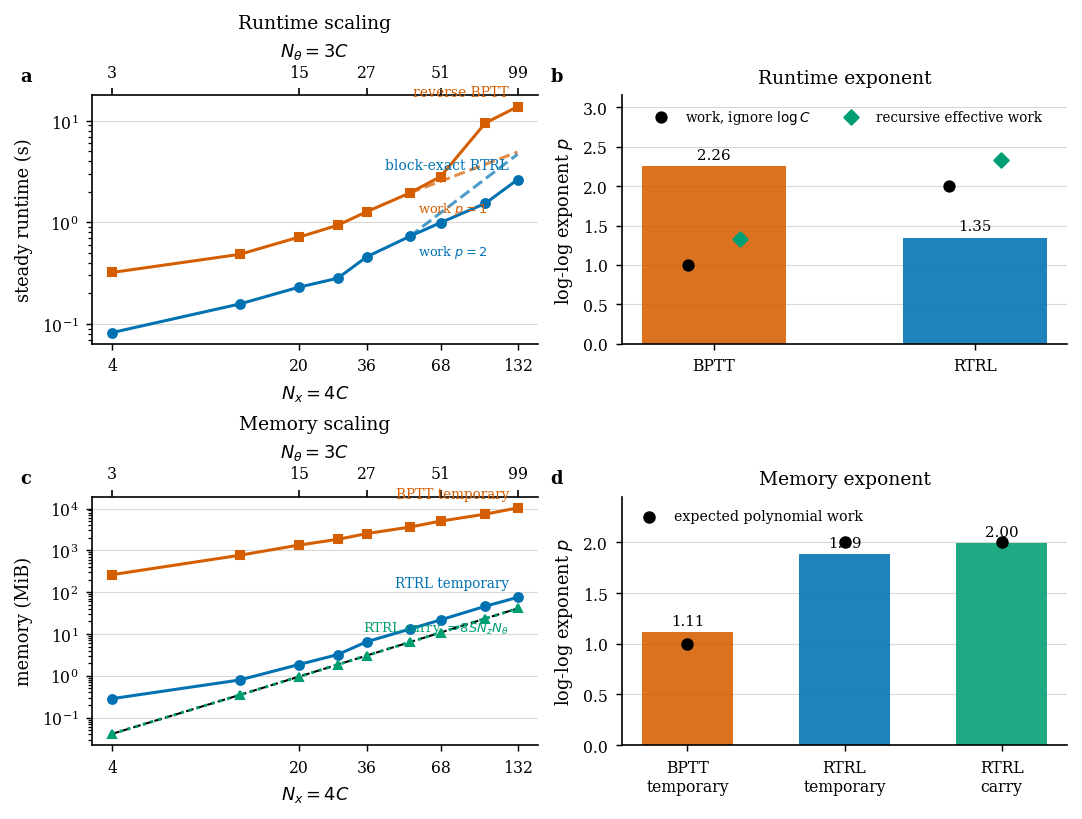

,method,measured_wall_clock_p,polynomial_work_p,recursive_effective_work_p
0,bptt,2.26,1.0,1.33
1,rtrl,1.35,2.0,2.33


,n_cv,n_x,n_x_block,n_theta,n_z,method,steady_median_seconds,temporary_bytes,rtrl_carry_bytes,gpu_peak_steady_bytes,bptt_over_rtrl_time
36,13,52,832,39,1336,bptt,1.943324,3777343824,NaN,4833935360,2.674548
37,13,52,832,39,1336,rtrl,0.726599,13676728,6669312.0,499122176,2.674548
38,17,68,1088,51,1744,bptt,2.830310,5259703752,NaN,9135194112,2.845733
39,17,68,1088,51,1744,rtrl,0.994580,22855864,11384832.0,507510784,2.845733
40,25,100,1600,75,2560,bptt,9.516540,7720923016,NaN,9185525760,6.182366
41,25,100,1600,75,2560,rtrl,1.539304,48384184,24576000.0,587202560,6.182366
42,33,132,2112,99,3376,bptt,13.779898,10847259232,NaN,17811111936,5.230855
43,33,132,2112,99,3376,rtrl,2.634349,78672824,42780672.0,658505728,5.230855


saved:
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/fig02_large_cv_complexity.pdf
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/fig02_large_cv_complexity.png


In [11]:
cv_rows = axis_slice("n_cv").copy()
cv_rows["n_x"] = (4 * cv_rows.n_cv).astype(np.int64)
cv_rows["n_x_block"] = cv_rows.active_state_estimate_per_seed.astype(np.int64)
cv_rows["n_theta"] = cv_rows.parameter_count_per_seed.astype(np.int64)
cv_rows["n_z"] = cv_rows.state_scalar_count_per_seed.astype(np.int64)

expected_n_x = 4 * cv_rows.n_cv
expected_n_x_block = cv_rows.batch_size * expected_n_x
expected_n_theta = 3 * cv_rows.n_cv
expected_n_z = (6 * cv_rows.batch_size + 6) * cv_rows.n_cv + 10
np.testing.assert_array_equal(cv_rows.n_x, expected_n_x)
np.testing.assert_array_equal(cv_rows.n_x_block, expected_n_x_block)
np.testing.assert_array_equal(cv_rows.n_theta, expected_n_theta)
np.testing.assert_array_equal(cv_rows.n_z, expected_n_z)

rtrl_cv = cv_rows[cv_rows.method == "rtrl"].sort_values("n_x").copy()
rtrl_cv["exact_carry_bytes"] = 8 * rtrl_cv.n_seed * rtrl_cv.n_z * rtrl_cv.n_theta
np.testing.assert_array_equal(rtrl_cv.rtrl_carry_bytes.astype(np.int64), rtrl_cv.exact_carry_bytes)

FIT_MIN_CV = 13
EXPECTED_EXPONENT = {"bptt": 1.0, "rtrl": 2.0}


def loglog_exponent(rows, metric):
    selected = rows[rows.n_cv >= FIT_MIN_CV]
    values = selected[["n_x", metric]].to_numpy(dtype=float)
    if len(values) < 2 or np.any(values <= 0):
        raise ValueError(f"Need at least two positive large-CV points for {metric}.")
    return np.polyfit(np.log(values[:, 0]), np.log(values[:, 1]), 1)[0]


def anchored_reference(rows, metric, exponent):
    anchor = rows[rows.n_cv == FIT_MIN_CV]
    if len(anchor) != 1:
        raise ValueError(f"Expected one C={FIT_MIN_CV} anchor for {metric}.")
    anchor = anchor.iloc[0]
    return rows[metric].loc[anchor.name] * (rows.n_x / anchor.n_x) ** exponent


batch_size = int(cv_rows.batch_size.iloc[0])
if cv_rows.batch_size.nunique() != 1:
    raise ValueError("The Large-CV comparison requires a fixed batch size.")


fit_rows = []
for method in ("bptt", "rtrl"):
    rows = cv_rows[cv_rows.method == method].sort_values("n_x")
    fit_rows.extend(
        [
            {
                "metric": "runtime",
                "method": method,
                "measured_p": loglog_exponent(rows, "steady_median_seconds"),
                "expected_p": EXPECTED_EXPONENT[method],
            },
            {
                "metric": "temporary",
                "method": method,
                "measured_p": loglog_exponent(rows, "temporary_bytes"),
                "expected_p": EXPECTED_EXPONENT[method],
            },
        ]
    )
carry_exponent = loglog_exponent(rtrl_cv, "rtrl_carry_bytes")
fit_rows.append({"metric": "carry", "method": "rtrl", "measured_p": carry_exponent, "expected_p": 2.0})
fit_summary = pd.DataFrame(fit_rows)
large = cv_rows[cv_rows.n_cv >= FIT_MIN_CV].copy()
runtime_methods = ("bptt", "rtrl")
runtime_fit = fit_summary[fit_summary.metric == "runtime"].set_index("method").loc[list(runtime_methods)]
measured_runtime_p = runtime_fit.measured_p.to_numpy(dtype=float)
polynomial_runtime_p = np.asarray([EXPECTED_EXPONENT[method] for method in runtime_methods])
fit_cv = np.sort(large.n_cv.unique().astype(float))
log_factor_p = np.polyfit(np.log(fit_cv), np.log(np.log2(fit_cv)), 1)[0]
recursive_runtime_p = polynomial_runtime_p + log_factor_p
memory_labels = ("BPTT\ntemporary", "RTRL\ntemporary", "RTRL\ncarry")
measured_memory_p = np.asarray(
    [
        fit_summary.query("metric == 'temporary' and method == 'bptt'").measured_p.iloc[0],
        fit_summary.query("metric == 'temporary' and method == 'rtrl'").measured_p.iloc[0],
        carry_exponent,
    ]
)
expected_memory_p = np.asarray([1.0, 2.0, 2.0])

fig, axes = plt.subplots(2, 2, figsize=(FULL_WIDTH_IN, 5.35), constrained_layout=True)
runtime_panel, runtime_p_panel, memory_panel, memory_p_panel = axes.flat
for method in runtime_methods:
    rows = cv_rows[cv_rows.method == method].sort_values("n_x")
    theory_rows = rows[rows.n_cv >= FIT_MIN_CV]
    measured_p = runtime_fit.loc[method, "measured_p"]
    runtime_panel.plot(rows.n_x, rows.steady_median_seconds, color=COLORS[method], marker=MARKERS[method])
    theory_values = anchored_reference(theory_rows, "steady_median_seconds", EXPECTED_EXPONENT[method])
    runtime_panel.plot(theory_rows.n_x, theory_values, color=COLORS[method], linestyle="--", alpha=0.7)
    runtime_panel.annotate(
        LABELS[method],
        (rows.n_x.iloc[-1], rows.steady_median_seconds.iloc[-1]),
        xytext=(-4, 5),
        textcoords="offset points",
        ha="right",
        color=COLORS[method],
        fontsize=6.7,
    )
    runtime_panel.annotate(
        f"work $p={EXPECTED_EXPONENT[method]:.0f}$",
        (theory_rows.n_x.iloc[0], theory_values.iloc[0]),
        xytext=(4, -9),
        textcoords="offset points",
        color=COLORS[method],
        fontsize=6.2,
    )
style_panel(runtime_panel, log_y=True)
runtime_panel.set_xscale("log")
runtime_panel.set(xlabel=r"$N_x = 4C$", ylabel="steady runtime (s)", title="Runtime scaling")
add_model_size_axis(runtime_panel, cv_rows, label=True)

x_runtime = np.arange(len(runtime_methods))
runtime_bars = runtime_p_panel.bar(
    x_runtime, measured_runtime_p, width=0.55, color=[COLORS[m] for m in runtime_methods], alpha=0.88
)
runtime_p_panel.scatter(
    x_runtime - 0.10, polynomial_runtime_p, color="black", marker="o", s=24, zorder=3, label=r"work, ignore $\log C$"
)
runtime_p_panel.scatter(
    x_runtime + 0.10,
    recursive_runtime_p,
    color=COLORS["carry"],
    marker="D",
    s=24,
    zorder=3,
    label="recursive effective work",
)
runtime_p_panel.bar_label(runtime_bars, fmt="%.2f", padding=2, fontsize=7.2)
runtime_p_panel.set_xticks(x_runtime, ["BPTT", "RTRL"])
runtime_p_panel.set(ylabel=r"log-log exponent $p$", title="Runtime exponent", ylim=(0, 3.15))
style_panel(runtime_p_panel)
runtime_p_panel.legend(fontsize=6.5, loc="upper center", ncol=2)

for method in runtime_methods:
    rows = cv_rows[cv_rows.method == method].sort_values("n_x")
    memory_values = rows.temporary_bytes / 2**20
    memory_panel.plot(rows.n_x, memory_values, color=COLORS[method], marker=MARKERS[method])
    memory_panel.annotate(
        f"{method.upper()} temporary",
        (rows.n_x.iloc[-1], memory_values.iloc[-1]),
        xytext=(-4, 5),
        textcoords="offset points",
        ha="right",
        color=COLORS[method],
        fontsize=6.5,
    )
memory_panel.plot(rtrl_cv.n_x, rtrl_cv.exact_carry_bytes / 2**20, color="black", linestyle="--", linewidth=1.0)
memory_panel.plot(
    rtrl_cv.n_x, rtrl_cv.rtrl_carry_bytes / 2**20, color=COLORS["carry"], marker=MARKERS["carry"], linestyle=":"
)
memory_panel.annotate(
    r"RTRL carry $=8SN_zN_\theta$",
    (rtrl_cv.n_x.iloc[-1], (rtrl_cv.rtrl_carry_bytes / 2**20).iloc[-1]),
    xytext=(-4, -11),
    textcoords="offset points",
    ha="right",
    color=COLORS["carry"],
    fontsize=6.3,
)
style_panel(memory_panel, log_y=True)
memory_panel.set_xscale("log")
memory_panel.set(xlabel=r"$N_x = 4C$", ylabel="memory (MiB)", title="Memory scaling")
add_model_size_axis(memory_panel, cv_rows, label=True)

x_memory = np.arange(len(memory_labels))
memory_bars = memory_p_panel.bar(
    x_memory, measured_memory_p, width=0.58, color=[COLORS["bptt"], COLORS["rtrl"], COLORS["carry"]], alpha=0.88
)
memory_p_panel.scatter(
    x_memory, expected_memory_p, color="black", marker="o", s=25, zorder=3, label="expected polynomial work"
)
memory_p_panel.bar_label(memory_bars, fmt="%.2f", padding=2, fontsize=7.2)
memory_p_panel.set_xticks(x_memory, memory_labels)
memory_p_panel.set(ylabel=r"log-log exponent $p$", title="Memory exponent", ylim=(0, 2.45))
style_panel(memory_p_panel)
memory_p_panel.legend(fontsize=6.8, loc="upper left")
add_panel_labels(axes)
figure2_paths = save_figure(fig, "fig02_large_cv_complexity")
plt.show()

exponent_comparison = pd.DataFrame(
    {
        "method": runtime_methods,
        "measured_wall_clock_p": measured_runtime_p,
        "polynomial_work_p": polynomial_runtime_p,
        "recursive_effective_work_p": recursive_runtime_p,
    }
)
display(exponent_comparison.round(2))
large_summary = large[
    [
        "n_cv",
        "n_x",
        "n_x_block",
        "n_theta",
        "n_z",
        "method",
        "steady_median_seconds",
        "temporary_bytes",
        "rtrl_carry_bytes",
        "gpu_peak_steady_bytes",
        "bptt_over_rtrl_time",
    ]
]
display(large_summary)
print("saved:", *(str(path) for path in figure2_paths), sep="\n  ")

## Figure 3 — Batch/seed static-shape cliff

这里的 `batch_size` 是一次梯度调用中的全部电流协议数。batch 位于每个 seed 的 Cell/Hines solve 内部，seed 则在完整梯度函数外层通过 `vmap` 映射。`B32/S16` 的慢路径主要来自 CUDA Graph dispatch；padding 只改变静态 execution shape，并裁掉额外 seed 输出。

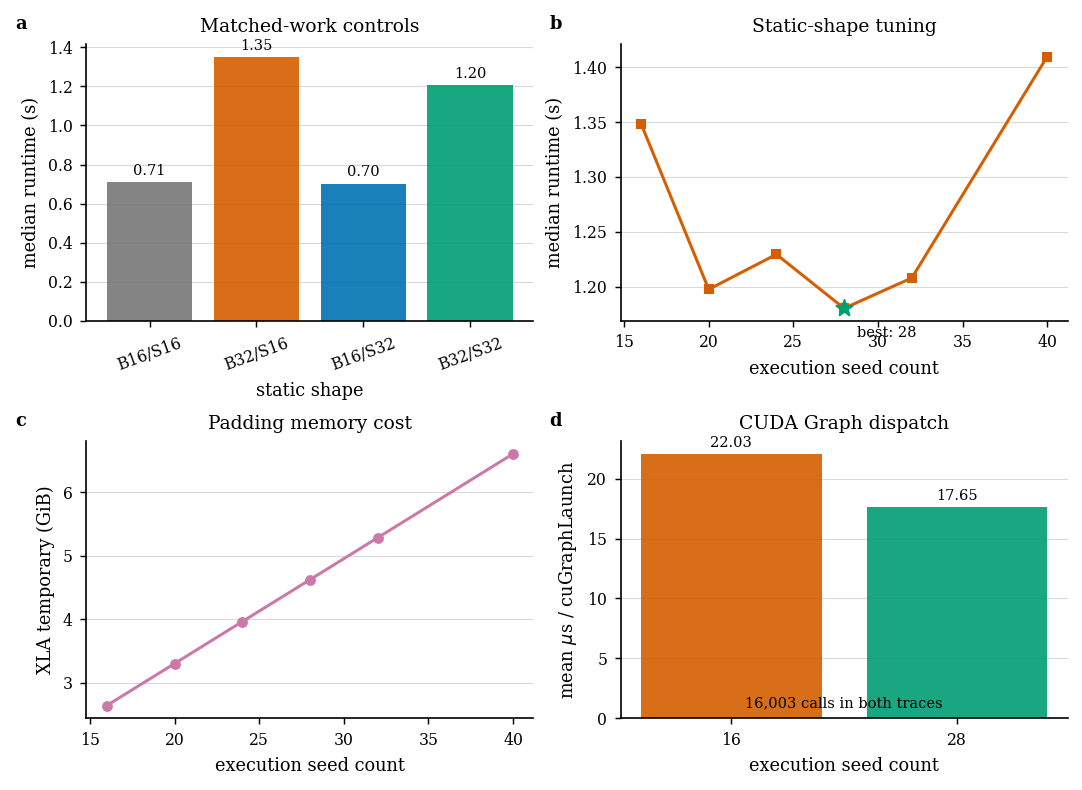

,execution_seed_count,median_seconds,p90_seconds,temporary_gib,gradient_relative_l2
5,16,1.349,1.350,2.64,0.000000e+00
0,20,1.197,1.198,3.30,2.000000e-11
1,24,1.229,1.230,3.96,2.200000e-11
2,28,1.180,1.181,4.63,3.100000e-11
3,32,1.208,1.210,5.29,3.100000e-11
4,40,1.410,1.410,6.61,1.900000e-11


saved:
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/fig03_batch_seed_shape.pdf
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/fig03_batch_seed_shape.png


In [12]:
if not batch_profile_available:
    print("Run the rtrl_bptt_gradient profiling case to populate Figure 3 artifacts.")
else:
    fig, axes = plt.subplots(2, 2, figsize=(FULL_WIDTH_IN, 5.15), constrained_layout=True)
    matched_panel, latency_panel, memory_panel, dispatch_panel = axes.flat
    matched_colors = ["#777777", COLORS["bptt"], COLORS["rtrl"], COLORS["carry"]]
    bars = matched_panel.bar(core_profile["shape"], core_profile.median_seconds, color=matched_colors, alpha=0.9)
    matched_panel.bar_label(bars, fmt="%.2f", padding=2, fontsize=7.0)
    matched_panel.set(xlabel="static shape", ylabel="median runtime (s)", title="Matched-work controls")
    matched_panel.tick_params(axis="x", rotation=20)
    style_panel(matched_panel)

    best = padding_profile.loc[padding_profile.median_seconds.idxmin()]
    latency_panel.plot(
        padding_profile.execution_seed_count,
        padding_profile.median_seconds,
        color=COLORS["bptt"],
        marker=MARKERS["bptt"],
    )
    latency_panel.scatter(
        [best.execution_seed_count], [best.median_seconds], color=COLORS["carry"], marker="*", s=65, zorder=4
    )
    latency_panel.annotate(
        f"best: {int(best.execution_seed_count)}",
        (best.execution_seed_count, best.median_seconds),
        xytext=(6, -14),
        textcoords="offset points",
        fontsize=7.0,
    )
    latency_panel.set(xlabel="execution seed count", ylabel="median runtime (s)", title="Static-shape tuning")
    style_panel(latency_panel)

    memory_panel.plot(padding_profile.execution_seed_count, padding_profile.temporary_gib, color="#CC79A7", marker="o")
    memory_panel.set(xlabel="execution seed count", ylabel="XLA temporary (GiB)", title="Padding memory cost")
    style_panel(memory_panel)

    if nsys_profile.empty:
        dispatch_panel.text(
            0.5, 0.5, "Nsight summary unavailable", ha="center", va="center", transform=dispatch_panel.transAxes
        )
        dispatch_panel.set_axis_off()
    else:
        dispatch_bars = dispatch_panel.bar(
            nsys_profile.execution_seed_count.astype(str),
            nsys_profile.cuGraphLaunch_mean_us,
            color=[COLORS["bptt"], COLORS["carry"]],
            alpha=0.9,
        )
        dispatch_panel.bar_label(dispatch_bars, fmt="%.2f", padding=2, fontsize=7.0)
        dispatch_panel.set(
            xlabel="execution seed count", ylabel=r"mean $\mu$s / cuGraphLaunch", title="CUDA Graph dispatch"
        )
        dispatch_panel.text(
            0.5,
            0.04,
            f"{int(nsys_profile.cuGraphLaunch_calls.iloc[0]):,} calls in both traces",
            ha="center",
            transform=dispatch_panel.transAxes,
            fontsize=7.0,
        )
        style_panel(dispatch_panel)
    add_panel_labels(axes)
    figure3_paths = save_figure(fig, "fig03_batch_seed_shape")
    plt.show()
    shape_summary = padding_profile[
        ["execution_seed_count", "median_seconds", "p90_seconds", "temporary_gib", "gradient_relative_l2"]
    ]
    display(
        shape_summary.round({"median_seconds": 3, "p90_seconds": 3, "temporary_gib": 2, "gradient_relative_l2": 12})
    )
    print("saved:", *(str(path) for path in figure3_paths), sep="\n  ")

## Figure 4 — Controlled complexity validation

Full-HH 上排展示 complete-gradient runtime：固定全区域共享的三个 conductance 改变 `Nx=4C`，以及固定 `Nx=132` 改变 Leak sharing；下排沿相同两个轴展示 XLA `temporary_bytes`。D 面板只显示 `all/population/CV`，`row/528` 保留为 cross-batch zero-sensitivity 诊断而不进入主图。虚线从每种方法最小尺寸的实测值出发，表示理论增长斜率；runtime 误差线是三个独立 worker median 的 min–max。Synthetic controlled 结果移到 Supplementary Figure S4。

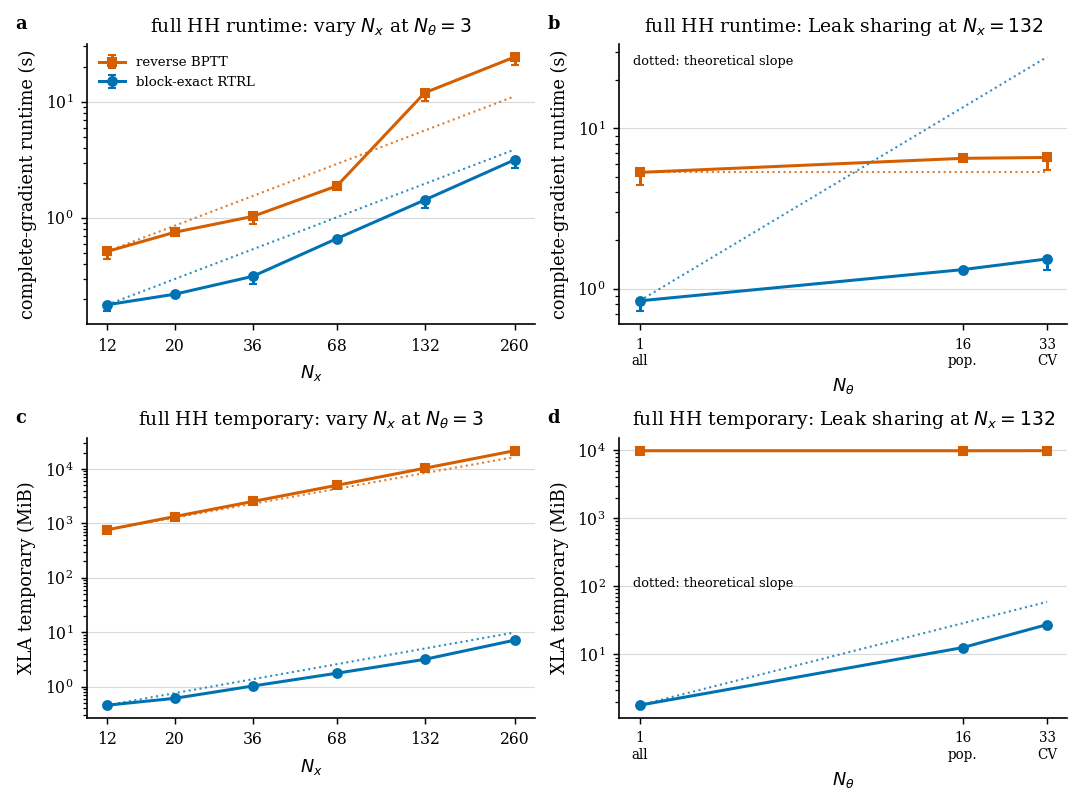

,workload,axis,metric,method,all_slope,all_r_squared,largest4_slope,largest4_r_squared
0,full HH runtime: vary $N_x$ at $N_\theta=3$,n_x,wall_clock,bptt,1.312,0.934,1.718,0.958
1,full HH runtime: vary $N_x$ at $N_\theta=3$,n_x,wall_clock,rtrl,0.963,0.975,1.167,1.000
2,full HH runtime: Leak sharing at $N_x=132$,n_theta,wall_clock,bptt,0.064,0.978,0.064,0.978
3,full HH runtime: Leak sharing at $N_x=132$,n_theta,wall_clock,rtrl,0.169,0.997,0.169,0.997
4,full HH temporary: vary $N_x$ at $N_\theta=3$,n_x,temporary_bytes,bptt,1.086,1.000,1.087,1.000
5,full HH temporary: vary $N_x$ at $N_\theta=3$,n_x,temporary_bytes,rtrl,0.891,0.991,0.972,0.993
6,full HH temporary: Leak sharing at $N_x=132$,n_theta,temporary_bytes,bptt,0.000,0.441,0.000,0.441
7,full HH temporary: Leak sharing at $N_x=132$,n_theta,temporary_bytes,rtrl,0.759,0.993,0.759,0.993


,workload,method,temporary_bytes,gpu_peak_steady_bytes
0,hh_parameter,bptt,1.032633e+10,1.773142e+10
1,hh_parameter,rtrl,2.099905e+07,6.312428e+08
2,hh_state,bptt,3.954233e+09,6.942622e+09
3,hh_state,rtrl,1.471776e+06,4.949279e+08


worst controlled elementwise relative error: 7.622e-07
worst controlled relative-L2 error: 3.169e-08
saved:
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/fig04_controlled_complexity.pdf
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/fig04_controlled_complexity.png


In [13]:
controlled_expected_rows = 22 * 2 * 3
if len(controlled_ok) != controlled_expected_rows:
    print(
        f"Run controlled complexity suite: expected {controlled_expected_rows} successful rows, found {len(controlled_ok)}."
    )
else:
    controlled = controlled_ok.copy()
    assert controlled.groupby(["config_id", "method"]).replicate.nunique().eq(3).all()
    synthetic = controlled[controlled.workload == "synthetic"]
    hh_state = controlled[controlled.workload == "hh_state"]
    hh_parameter = controlled[controlled.workload == "hh_parameter"]
    hh_parameter_figure = hh_parameter[hh_parameter.parameter_group != "row"].copy()
    assert synthetic[(synthetic.n_theta == 8)].n_x.nunique() == 6
    assert synthetic[(synthetic.n_x == 512)].n_theta.nunique() == 7
    assert hh_state.n_theta.eq(3).all() and hh_state.n_x.eq(4 * hh_state.n_cv).all()
    assert set(hh_parameter_figure.n_theta.astype(int)) == {1, 16, 33}
    synthetic_rtrl = synthetic[synthetic.method == "rtrl"]
    expected_carry = 8 * synthetic_rtrl.n_seed * synthetic_rtrl.batch_size * synthetic_rtrl.n_x * synthetic_rtrl.n_theta
    np.testing.assert_array_equal(synthetic_rtrl.rtrl_carry_bytes.astype(np.int64), expected_carry.astype(np.int64))

    def worker_summary(rows, x_column, metric):
        return (
            rows.groupby([x_column, "method"], as_index=False)[metric]
            .agg(["median", "min", "max"])
            .reset_index()
            .sort_values(["method", x_column])
        )

    def exponent_fit(rows, x_column, *, largest=None):
        selected = rows.sort_values(x_column)
        if largest is not None:
            selected = selected.tail(largest)
        x = np.log(selected[x_column].to_numpy(dtype=float))
        y = np.log(selected["median"].to_numpy(dtype=float))
        slope, intercept = np.polyfit(x, y, 1)
        prediction = intercept + slope * x
        residual = np.sum((y - prediction) ** 2)
        total = np.sum((y - y.mean()) ** 2)
        r_squared = 1.0 if np.isclose(total, 0.0) and np.isclose(residual, 0.0) else 1.0 - residual / total
        return float(slope), float(r_squared)

    def render_controlled_panels(panels, stem, *, group_parameter_axis=False):
        fig, axes = plt.subplots(2, 2, figsize=(FULL_WIDTH_IN, 5.25), constrained_layout=True)
        fit_rows = []
        for panel, (rows, x_column, metric, scale, ylabel, title, expected) in zip(axes.flat, panels):
            summary_rows = worker_summary(rows, x_column, metric)
            for method in ("bptt", "rtrl"):
                method_rows = summary_rows[summary_rows.method == method]
                if metric == "steady_median_seconds":
                    yerr = (
                        np.vstack(
                            [method_rows["median"] - method_rows["min"], method_rows["max"] - method_rows["median"]]
                        )
                        / scale
                    )
                    panel.errorbar(
                        method_rows[x_column],
                        method_rows["median"] / scale,
                        yerr=yerr,
                        color=COLORS[method],
                        marker=MARKERS[method],
                        capsize=2.0,
                        label=LABELS[method],
                    )
                else:
                    panel.plot(
                        method_rows[x_column],
                        method_rows["median"] / scale,
                        color=COLORS[method],
                        marker=MARKERS[method],
                        label=LABELS[method],
                    )
                all_slope, all_r_squared = exponent_fit(method_rows, x_column)
                large_slope, large_r_squared = exponent_fit(method_rows, x_column, largest=min(4, len(method_rows)))
                fit_rows.append(
                    {
                        "workload": title,
                        "axis": x_column,
                        "metric": "wall_clock" if metric == "steady_median_seconds" else metric,
                        "method": method,
                        "all_slope": all_slope,
                        "all_r_squared": all_r_squared,
                        "largest4_slope": large_slope,
                        "largest4_r_squared": large_r_squared,
                    }
                )
                reference = (
                    method_rows["median"].iloc[0]
                    * (method_rows[x_column] / method_rows[x_column].iloc[0]) ** expected[method]
                )
                panel.plot(
                    method_rows[x_column],
                    reference / scale,
                    color=COLORS[method],
                    linestyle=":",
                    linewidth=1.0,
                    alpha=0.8,
                )
            panel.set_xscale("log", base=2)
            panel.set_yscale("log")
            panel.set(
                xlabel=x_column.replace("n_x", r"$N_x$").replace("n_theta", r"$N_\theta$"), ylabel=ylabel, title=title
            )
            x_values = sorted(rows[x_column].unique())
            x_labels = [str(int(value)) for value in x_values]
            if group_parameter_axis and x_column == "n_theta":
                group_labels = dict(rows[[x_column, "parameter_group"]].drop_duplicates().to_numpy())
                compact_group = {"all": "all", "population": "pop.", "cv": "CV"}
                x_labels = [f"{int(value)}\n{compact_group[group_labels[value]]}" for value in x_values]
                panel.tick_params(axis="x", labelsize=6.5)
            panel.set_xticks(x_values, labels=x_labels)
            panel.xaxis.set_minor_locator(NullLocator())
            style_panel(panel)
        axes[0, 0].legend(fontsize=6.4)
        axes[0, 1].text(
            0.03, 0.96, "dotted: theoretical slope", transform=axes[0, 1].transAxes, ha="left", va="top", fontsize=6.2
        )
        axes[1, 1].text(
            0.03,
            0.48,
            "dotted: theoretical slope",
            transform=axes[1, 1].transAxes,
            ha="left",
            va="center",
            fontsize=6.2,
        )
        add_panel_labels(axes)
        paths = save_figure(fig, stem)
        plt.show()
        return paths, pd.DataFrame(fit_rows)

    hh_panels = (
        (
            hh_state,
            "n_x",
            "steady_median_seconds",
            1.0,
            "complete-gradient runtime (s)",
            r"full HH runtime: vary $N_x$ at $N_\theta=3$",
            {"bptt": 1.0, "rtrl": 1.0},
        ),
        (
            hh_parameter_figure,
            "n_theta",
            "steady_median_seconds",
            1.0,
            "complete-gradient runtime (s)",
            r"full HH runtime: Leak sharing at $N_x=132$",
            {"bptt": 0.0, "rtrl": 1.0},
        ),
        (
            hh_state,
            "n_x",
            "temporary_bytes",
            2**20,
            "XLA temporary (MiB)",
            r"full HH temporary: vary $N_x$ at $N_\theta=3$",
            {"bptt": 1.0, "rtrl": 1.0},
        ),
        (
            hh_parameter_figure,
            "n_theta",
            "temporary_bytes",
            2**20,
            "XLA temporary (MiB)",
            r"full HH temporary: Leak sharing at $N_x=132$",
            {"bptt": 0.0, "rtrl": 1.0},
        ),
    )
    figure4_paths, hh_fits = render_controlled_panels(
        hh_panels, "fig04_controlled_complexity", group_parameter_axis=True
    )
    display(hh_fits.round(3))
    display(
        controlled[controlled.workload.isin(["hh_state", "hh_parameter"])]
        .groupby(["workload", "method"])[["temporary_bytes", "gpu_peak_steady_bytes"]]
        .median()
        .reset_index()
    )
    print(f"worst controlled elementwise relative error: {controlled.gradient_max_rel_error.max():.3e}")
    print(f"worst controlled relative-L2 error: {controlled.gradient_relative_l2_error.max():.3e}")
    print("saved:", *(str(path) for path in figure4_paths), sep="\n  ")

## Supplementary Figure S4 — Synthetic controlled complexity

与 Figure 4 相同的 runtime/temporary 四面板布局应用于 synthetic recurrence：固定 `Nθ=8` 改变 `Nx`，以及固定 `Nx=512` 改变 `Nθ`。该图用于验证纯算法阶数；下方表格同时报告 wall-clock、XLA temporary 和 compiler-flop 指数。

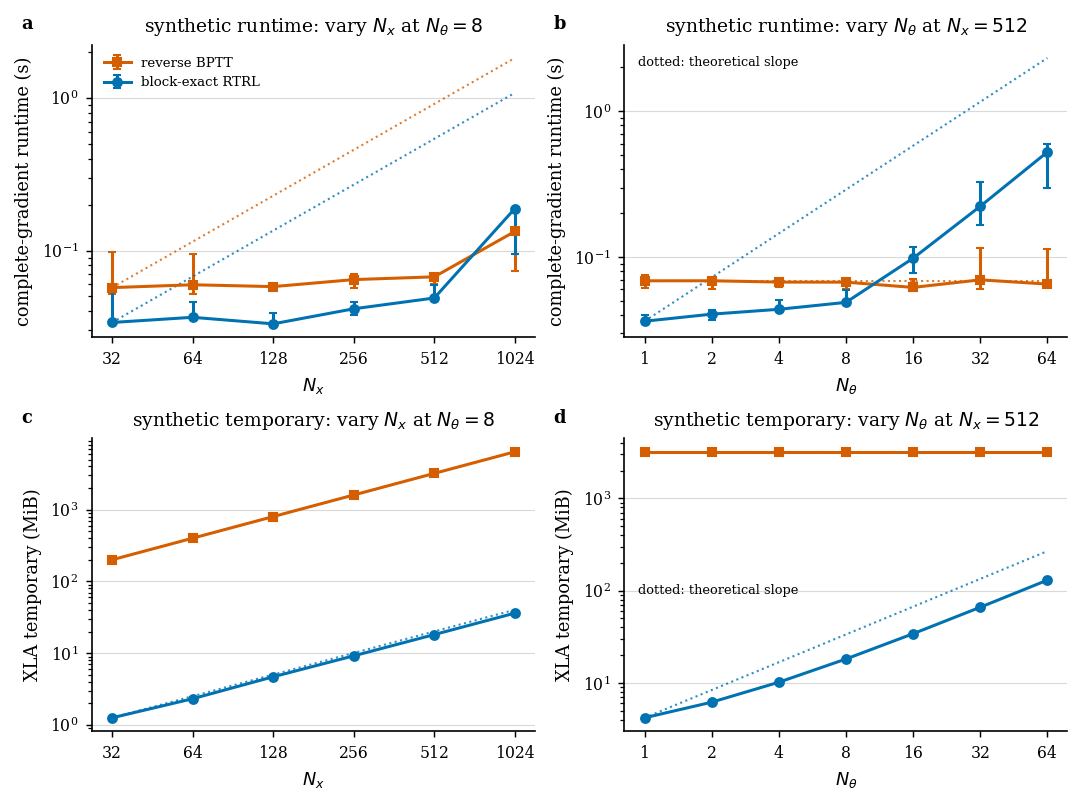

,workload,axis,metric,method,all_slope,all_r_squared,largest4_slope,largest4_r_squared
0,synthetic runtime: vary $N_x$ at $N_\theta=8$,n_x,wall_clock,bptt,0.194,0.601,0.367,0.748
1,synthetic runtime: vary $N_x$ at $N_\theta=8$,n_x,wall_clock,rtrl,0.400,0.605,0.777,0.786
2,synthetic runtime: vary $N_\theta$ at $N_x=512$,n_theta,wall_clock,bptt,-0.011,0.159,0.004,0.005
3,synthetic runtime: vary $N_\theta$ at $N_x=512$,n_theta,wall_clock,rtrl,0.630,0.851,1.146,0.998
4,synthetic temporary: vary $N_x$ at $N_\theta=8$,n_x,temporary_bytes,bptt,1.000,1.000,1.000,1.000
5,synthetic temporary: vary $N_x$ at $N_\theta=8$,n_x,temporary_bytes,rtrl,0.975,1.000,0.982,1.000
6,synthetic temporary: vary $N_\theta$ at $N_x=512$,n_theta,temporary_bytes,bptt,0.000,1.000,-0.000,1.000
7,synthetic temporary: vary $N_\theta$ at $N_x=512$,n_theta,temporary_bytes,rtrl,0.837,0.993,0.947,1.000
8,synthetic runtime: vary $N_x$ at $N_\theta=8$,n_x,compiler_flops,bptt,0.967,1.000,0.986,1.000
9,synthetic runtime: vary $N_x$ at $N_\theta=8$,n_x,compiler_flops,rtrl,0.992,1.000,0.997,1.000


,method,compiler_flops,temporary_bytes,gpu_peak_steady_bytes
0,bptt,3048485.0,3.358795e+09,4.815061e+09
1,rtrl,7306322.0,1.016670e+07,4.865393e+08


saved:
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/figS4_synthetic_controlled_complexity.pdf
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/figS4_synthetic_controlled_complexity.png


In [14]:
if len(controlled_ok) != controlled_expected_rows:
    print(
        f"Run controlled complexity suite: expected {controlled_expected_rows} successful rows, found {len(controlled_ok)}."
    )
else:
    state_axis = synthetic[synthetic.n_theta == 8]
    parameter_axis = synthetic[synthetic.n_x == 512]
    synthetic_panels = (
        (
            state_axis,
            "n_x",
            "steady_median_seconds",
            1.0,
            "complete-gradient runtime (s)",
            r"synthetic runtime: vary $N_x$ at $N_\theta=8$",
            {"bptt": 1.0, "rtrl": 1.0},
        ),
        (
            parameter_axis,
            "n_theta",
            "steady_median_seconds",
            1.0,
            "complete-gradient runtime (s)",
            r"synthetic runtime: vary $N_\theta$ at $N_x=512$",
            {"bptt": 0.0, "rtrl": 1.0},
        ),
        (
            state_axis,
            "n_x",
            "temporary_bytes",
            2**20,
            "XLA temporary (MiB)",
            r"synthetic temporary: vary $N_x$ at $N_\theta=8$",
            {"bptt": 1.0, "rtrl": 1.0},
        ),
        (
            parameter_axis,
            "n_theta",
            "temporary_bytes",
            2**20,
            "XLA temporary (MiB)",
            r"synthetic temporary: vary $N_\theta$ at $N_x=512$",
            {"bptt": 0.0, "rtrl": 1.0},
        ),
    )
    figure_s4_paths, synthetic_fits = render_controlled_panels(
        synthetic_panels, "figS4_synthetic_controlled_complexity"
    )
    compiler_rows = []
    for rows, x_column, _metric, _scale, _ylabel, title, _expected in synthetic_panels[:2]:
        compiler_summary = (
            rows.groupby([x_column, "method"], as_index=False)
            .compiler_flops.median()
            .rename(columns={"compiler_flops": "median"})
        )
        compiler_summary["min"] = compiler_summary["median"]
        compiler_summary["max"] = compiler_summary["median"]
        for method in ("bptt", "rtrl"):
            method_rows = compiler_summary[compiler_summary.method == method].sort_values(x_column)
            all_slope, all_r_squared = exponent_fit(method_rows, x_column)
            large_slope, large_r_squared = exponent_fit(method_rows, x_column, largest=min(4, len(method_rows)))
            compiler_rows.append(
                {
                    "workload": title,
                    "axis": x_column,
                    "metric": "compiler_flops",
                    "method": method,
                    "all_slope": all_slope,
                    "all_r_squared": all_r_squared,
                    "largest4_slope": large_slope,
                    "largest4_r_squared": large_r_squared,
                }
            )
    synthetic_fit_summary = pd.concat([synthetic_fits, pd.DataFrame(compiler_rows)], ignore_index=True)
    display(synthetic_fit_summary.round(3))
    display(
        synthetic.groupby("method")[["compiler_flops", "temporary_bytes", "gpu_peak_steady_bytes"]]
        .median()
        .reset_index()
    )
    print("saved:", *(str(path) for path in figure_s4_paths), sep="\n  ")

## Supplementary Figure S3 — Mechanism × trainable-subset ablation

固定 `T40/B16/S16`，在 `C={3,5,9,17,33}` 上改变 painted mechanism 与 trainable subset。每个 C 的六个 candidate 共用同一 full-HH target；target generation 不计时。该图只描述机制和可训练子集对 runtime/temporary memory 的应用级影响，不用于拟合或验证 `Nx/Nθ` 算法复杂度。

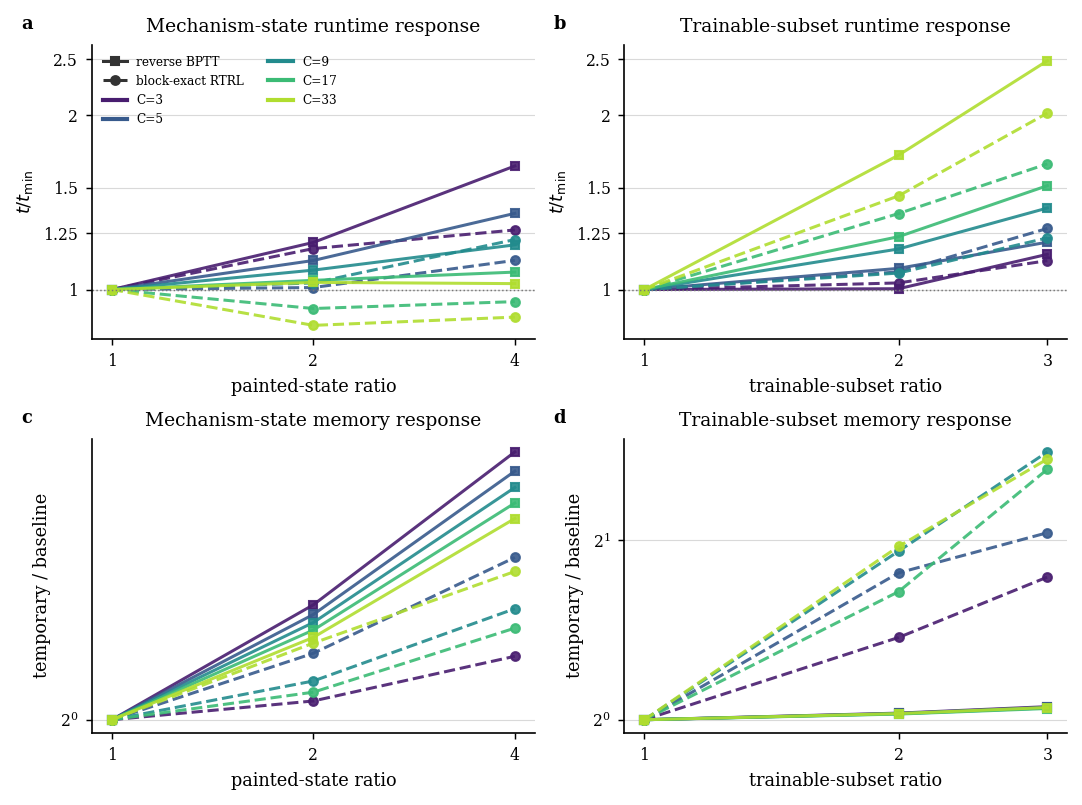

,mechanism_case,method,steady_median_seconds,temporary_bytes
0,l_fit_l,bptt,0.765649,1.439693e+09
1,l_fit_l,rtrl,0.303353,1.869896e+06
2,lk_fit_l,bptt,0.827174,1.823158e+09
3,lk_fit_l,rtrl,0.311432,2.054488e+06
4,lk_fit_lk,bptt,1.008495,1.882190e+09
5,lk_fit_lk,rtrl,0.385836,3.991416e+06
6,lkn_fit_l,bptt,0.914652,2.531078e+09
7,lkn_fit_l,rtrl,0.370139,2.448760e+06
8,lkn_fit_lk,bptt,1.075059,2.590110e+09
9,lkn_fit_lk,rtrl,0.395230,4.692120e+06


worst factorial gradient relative error: 7.640e-09
saved:
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/figS3_mechanism_factorial.pdf
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/figS3_mechanism_factorial.png


In [15]:
factorial_expected_rows = 5 * 6 * 2
if len(factorial_ok) != factorial_expected_rows:
    print(
        f"Run mechanism_factorial suite: expected {factorial_expected_rows} successful rows, found {len(factorial_ok)}."
    )
else:
    factorial = factorial_ok.sort_values(
        ["n_cv", "state_variables_per_cv", "trainable_channels_per_cv", "method"]
    ).copy()
    np.testing.assert_array_equal(factorial.n_x, factorial.n_cv * factorial.state_variables_per_cv)
    np.testing.assert_array_equal(factorial.n_theta, factorial.n_cv * factorial.trainable_channels_per_cv)
    factorial_rtrl = factorial[factorial.method == "rtrl"].copy()
    exact_factorial_carry = (
        8 * factorial_rtrl.n_seed * factorial_rtrl.state_scalar_count_per_seed * factorial_rtrl.n_theta
    )
    np.testing.assert_array_equal(
        factorial_rtrl.rtrl_carry_bytes.astype(np.int64), exact_factorial_carry.astype(np.int64)
    )

    cv_values = tuple(sorted(factorial.n_cv.unique()))
    controlled_slices = {}
    for method in ("bptt", "rtrl"):
        for n_cv in cv_values:
            state_rows = factorial[
                (factorial.method == method) & (factorial.n_cv == n_cv) & (factorial.trainable_channels_per_cv == 1)
            ].sort_values("n_x")
            parameter_rows = factorial[
                (factorial.method == method) & (factorial.n_cv == n_cv) & (factorial.state_variables_per_cv == 4)
            ].sort_values("n_theta")
            assert len(state_rows) == 3 and state_rows.n_theta.nunique() == 1
            assert len(parameter_rows) == 3 and parameter_rows.n_x.nunique() == 1
            assert state_rows.n_theta.iloc[0] == n_cv
            assert parameter_rows.n_x.iloc[0] == 4 * n_cv
            controlled_slices[(method, n_cv, "n_x")] = state_rows
            controlled_slices[(method, n_cv, "n_theta")] = parameter_rows

    fig, axes = plt.subplots(2, 2, figsize=(FULL_WIDTH_IN, 5.25), constrained_layout=True)
    state_panel, parameter_panel, state_memory_panel, parameter_memory_panel = axes.flat
    cv_palette = plt.get_cmap("viridis")(np.linspace(0.08, 0.88, len(cv_values)))
    cv_colors = dict(zip(cv_values, cv_palette))
    method_linestyles = {"bptt": "-", "rtrl": "--"}
    for n_cv in cv_values:
        for method in ("bptt", "rtrl"):
            state_rows = controlled_slices[(method, n_cv, "n_x")]
            state_panel.plot(
                state_rows.n_x / state_rows.n_x.iloc[0],
                state_rows.steady_median_seconds / state_rows.steady_median_seconds.iloc[0],
                color=cv_colors[n_cv],
                linestyle=method_linestyles[method],
                marker=MARKERS[method],
                alpha=0.9,
            )
            state_memory_panel.plot(
                state_rows.n_x / state_rows.n_x.iloc[0],
                state_rows.temporary_bytes / state_rows.temporary_bytes.iloc[0],
                color=cv_colors[n_cv],
                linestyle=method_linestyles[method],
                marker=MARKERS[method],
                alpha=0.9,
            )
            parameter_rows = controlled_slices[(method, n_cv, "n_theta")]
            parameter_panel.plot(
                parameter_rows.n_theta / parameter_rows.n_theta.iloc[0],
                parameter_rows.steady_median_seconds / parameter_rows.steady_median_seconds.iloc[0],
                color=cv_colors[n_cv],
                linestyle=method_linestyles[method],
                marker=MARKERS[method],
                alpha=0.9,
            )
            parameter_memory_panel.plot(
                parameter_rows.n_theta / parameter_rows.n_theta.iloc[0],
                parameter_rows.temporary_bytes / parameter_rows.temporary_bytes.iloc[0],
                color=cv_colors[n_cv],
                linestyle=method_linestyles[method],
                marker=MARKERS[method],
                alpha=0.9,
            )
    state_panel.set(xlabel="painted-state ratio", ylabel=r"$t/t_{\min}$", title="Mechanism-state runtime response")
    parameter_panel.set(
        xlabel="trainable-subset ratio", ylabel=r"$t/t_{\min}$", title="Trainable-subset runtime response"
    )
    for panel, ticks in ((state_panel, [1, 2, 4]), (parameter_panel, [1, 2, 3])):
        panel.set_xscale("log", base=2)
        panel.set_yscale("log", base=2)
        panel.set_xticks(ticks, labels=[str(value) for value in ticks])
        panel.set_yticks([1, 1.25, 1.5, 2, 2.5], labels=["1", "1.25", "1.5", "2", "2.5"])
        panel.set_ylim(0.82, 2.65)
        panel.xaxis.set_minor_locator(NullLocator())
        panel.yaxis.set_minor_locator(NullLocator())
        style_panel(panel)
        panel.axhline(1.0, color="#777777", linewidth=0.7, linestyle=":")
    factorial_method_handles = [
        Line2D(
            [], [], color="#333333", linestyle=method_linestyles[method], marker=MARKERS[method], label=LABELS[method]
        )
        for method in ("bptt", "rtrl")
    ]
    cv_handles = [Line2D([], [], color=cv_colors[n_cv], linewidth=2.0, label=f"C={n_cv}") for n_cv in cv_values]
    state_panel.legend(handles=factorial_method_handles + cv_handles, ncol=2, fontsize=5.8, loc="upper left")

    state_memory_panel.set(
        xlabel="painted-state ratio", ylabel="temporary / baseline", title=r"Mechanism-state memory response"
    )
    parameter_memory_panel.set(
        xlabel="trainable-subset ratio", ylabel="temporary / baseline", title=r"Trainable-subset memory response"
    )
    for panel, ticks in ((state_memory_panel, [1, 2, 4]), (parameter_memory_panel, [1, 2, 3])):
        panel.set_xscale("log", base=2)
        panel.set_yscale("log", base=2)
        panel.set_xticks(ticks, labels=[str(value) for value in ticks])
        panel.xaxis.set_minor_locator(NullLocator())
        panel.yaxis.set_minor_locator(NullLocator())
        style_panel(panel)
    add_panel_labels(axes)
    figure_s3_paths = save_figure(fig, "figS3_mechanism_factorial")
    plt.show()
    display(
        factorial.groupby(["mechanism_case", "method"])[["steady_median_seconds", "temporary_bytes"]]
        .median()
        .reset_index()
    )
    print(f"worst factorial gradient relative error: {factorial.gradient_max_rel_error.max():.3e}")
    print("saved:", *(str(path) for path in figure_s3_paths), sep="\n  ")

## Supplementary Figure S1 — Backsub and numerical agreement

固定 `T40/B16/S16`，比较 `C9/17/25/33`。颜色表示梯度方法，线型表示 backsub；第三个面板汇总所有主配置的 BPTT/RTRL 梯度相对误差。

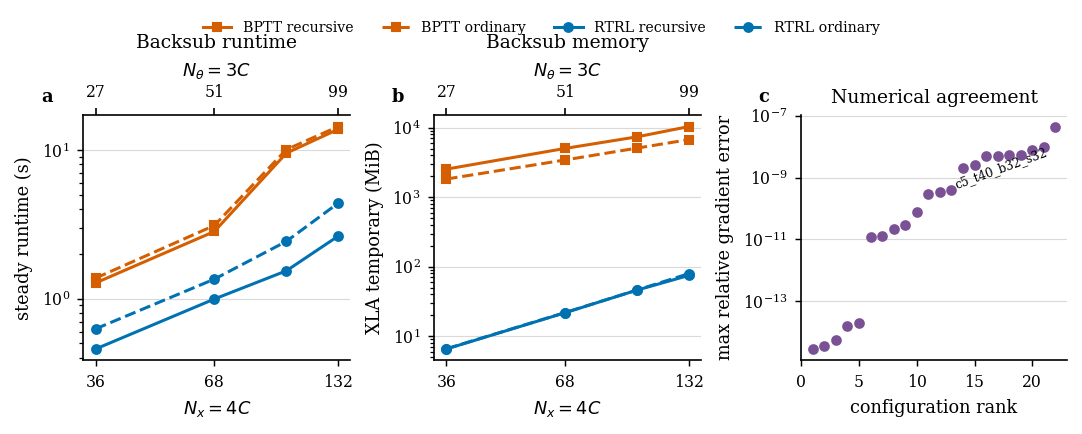

worst paired relative gradient error: 4.540e-08
worst paired absolute loss error: 6.776e-10
saved:
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/figS1_backsub_correctness.pdf
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/figS1_backsub_correctness.png


steady_median_seconds            temporary_bytes  \
backsub                                  ordinary  recursive        ordinary   
config_id       n_cv method                                                    
c17_t40_b16_s16 17   bptt                3.105854   2.830310    3.589519e+09   
                     rtrl                1.353377   0.994580    2.300742e+07   
c25_t40_b16_s16 25   bptt               10.057664   9.516540    5.315789e+09   
                     rtrl                2.428033   1.539304    4.850502e+07   
c33_t40_b16_s16 33   bptt               14.375604  13.779898    7.039670e+09   
                     rtrl                4.387939   2.634349    8.346335e+07   
c9_t40_b16_s16  9    bptt                1.374668   1.276080    1.908792e+09   
                     rtrl                0.626760   0.458880    6.927288e+06   

                                                          derived  \
backsub                         recursive ordinary/recursive time   
config_id       n_cv method                                         
c17_t40_b16_s16 17   bptt    5.259704e+09                1.097355   
                     rtrl    2.285586e+07                1.360752   
c25_t40_b16_s16 25   bptt    7.720923e+09                1.056861   
                     rtrl    4.838418e+07                1.577358   
c33_t40_b16_s16 33   bptt    1.084726e+10                1.043230   
                     rtrl    7.867282e+07                1.665664   
c9_t40_b16_s16  9    bptt    2.649135e+09                1.077258   
                     rtrl    6.878904e+06                1.365845   

                                                     
backsub                     ordinary/recursive temp  
config_id       n_cv method                          
c17_t40_b16_s16 17   bptt                  0.682456  
                     rtrl                  1.006631  
c25_t40_b16_s16 25   bptt                  0.688491  
                     rtrl                  1.002497  
c33_t40_b16_s16 33   bptt                  0.648981  
                     rtrl                  1.060892  
c9_t40_b16_s16  9    bptt                  0.720534  
                     rtrl                  1.007034

In [16]:
ab = all_ok[
    all_ok.n_cv.isin([9, 17, 25, 33]) & (all_ok.duration_ms == 40) & (all_ok.batch_size == 16) & (all_ok.n_seed == 16)
].copy()
ab["n_x"] = 4 * ab.n_cv
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH_IN, 2.65), constrained_layout=True)
runtime_panel, temporary_panel, error_panel = axes
backsub_styles = {"recursive": "-", "ordinary": "--"}
for method in ("bptt", "rtrl"):
    for backsub, style in backsub_styles.items():
        values = ab[(ab.method == method) & (ab.backsub == backsub)].sort_values("n_x")
        label = f"{method.upper()} {backsub}"
        runtime_panel.plot(
            values.n_x,
            values.steady_median_seconds,
            color=COLORS[method],
            marker=MARKERS[method],
            linestyle=style,
            label=label,
        )
        temporary_panel.plot(
            values.n_x,
            values.temporary_bytes / 2**20,
            color=COLORS[method],
            marker=MARKERS[method],
            linestyle=style,
            label=label,
        )
for panel, ylabel, title in (
    (runtime_panel, "steady runtime (s)", "Backsub runtime"),
    (temporary_panel, "XLA temporary (MiB)", "Backsub memory"),
):
    panel.set_xscale("log")
    style_panel(panel, log_y=True)
    panel.set(xlabel=r"$N_x = 4C$", ylabel=ylabel, title=title)
    add_model_size_axis(panel, ab, label=True)

error_x = np.arange(1, len(correctness) + 1)
error_panel.scatter(error_x, correctness.gradient_max_rel_error, color="#7A5195", s=17)
style_panel(error_panel, log_y=True)
error_panel.set(xlabel="configuration rank", ylabel="max relative gradient error", title="Numerical agreement")
for row in correctness.nlargest(1, "gradient_max_rel_error").itertuples():
    rank = int(correctness.index[correctness.config_id == row.config_id][0]) + 1
    error_panel.annotate(
        row.config_id,
        (rank, row.gradient_max_rel_error),
        xytext=(-3, -9),
        textcoords="offset points",
        fontsize=5.8,
        ha="right",
        va="top",
        rotation=20,
    )
fig.legend(
    handles=runtime_panel.get_legend_handles_labels()[0],
    labels=runtime_panel.get_legend_handles_labels()[1],
    loc="upper center",
    ncol=4,
    bbox_to_anchor=(0.5, 1.05),
    fontsize=6.8,
)
add_panel_labels(axes)
figure_s1_paths = save_figure(fig, "figS1_backsub_correctness")
plt.show()
print(f"worst paired relative gradient error: {worst_gradient_error:.3e}")
print(f"worst paired absolute loss error: {worst_loss_error:.3e}")
print("saved:", *(str(path) for path in figure_s1_paths), sep="\n  ")

ab_pivot = ab.pivot(
    index=["config_id", "n_cv", "method"], columns="backsub", values=["steady_median_seconds", "temporary_bytes"]
)
ab_pivot[("derived", "ordinary/recursive time")] = (
    ab_pivot[("steady_median_seconds", "ordinary")] / ab_pivot[("steady_median_seconds", "recursive")]
)
ab_pivot[("derived", "ordinary/recursive temp")] = (
    ab_pivot[("temporary_bytes", "ordinary")] / ab_pivot[("temporary_bytes", "recursive")]
)
display(ab_pivot)

In [17]:
def load_trial_arrays(row):
    return np.load(Path(row.result_directory) / "trials" / row.gradient_file)


backsub_errors = []
for (config_id, method), group in ab.groupby(["config_id", "method"]):
    modes = {row.backsub: row for row in group.itertuples()}
    if set(modes) != {"recursive", "ordinary"}:
        continue
    recursive = load_trial_arrays(modes["recursive"])
    ordinary = load_trial_arrays(modes["ordinary"])
    difference = np.abs(recursive["gradient"] - ordinary["gradient"])
    scale = np.maximum(np.abs(recursive["gradient"]), 1e-30)
    backsub_errors.append(
        {
            "config_id": config_id,
            "method": method,
            "gradient_max_abs_error": difference.max(),
            "gradient_max_rel_error": (difference / scale).max(),
            "loss_max_abs_error": np.max(np.abs(recursive["loss"] - ordinary["loss"])),
        }
    )
backsub_errors = pd.DataFrame(backsub_errors)
display(backsub_errors)
print("worst ordinary/recursive relative gradient error:", backsub_errors.gradient_max_rel_error.max())

,config_id,method,gradient_max_abs_error,gradient_max_rel_error,loss_max_abs_error
0,c17_t40_b16_s16,bptt,1.075089e-06,5.768022e-10,1.599005e-10
1,c17_t40_b16_s16,rtrl,5.647976e-07,3.036128e-10,4.168328e-10
2,c25_t40_b16_s16,bptt,2.527564e-05,1.270895e-08,3.515197e-10
3,c25_t40_b16_s16,rtrl,2.526458e-05,1.270339e-08,5.587708e-10
4,c33_t40_b16_s16,bptt,4.925980e-06,5.421827e-09,5.083649e-10
5,c33_t40_b16_s16,rtrl,9.546122e-06,5.413093e-09,3.337775e-10
6,c9_t40_b16_s16,bptt,1.405316e-05,4.931805e-09,2.874572e-10
7,c9_t40_b16_s16,rtrl,1.410732e-05,4.950816e-09,1.257376e-10


worst ordinary/recursive relative gradient error: 1.270894727246979e-08


## Supplementary Figure S2 — Compiler and process memory

Compile time 和 NVML process peak 对四个受控维度作图。GPU utilization、memory-controller utilization 与功耗压缩为范围表；接近 100% utilization 只表示设备在采样窗口内忙碌，不等价于达到峰值 FLOP/s。

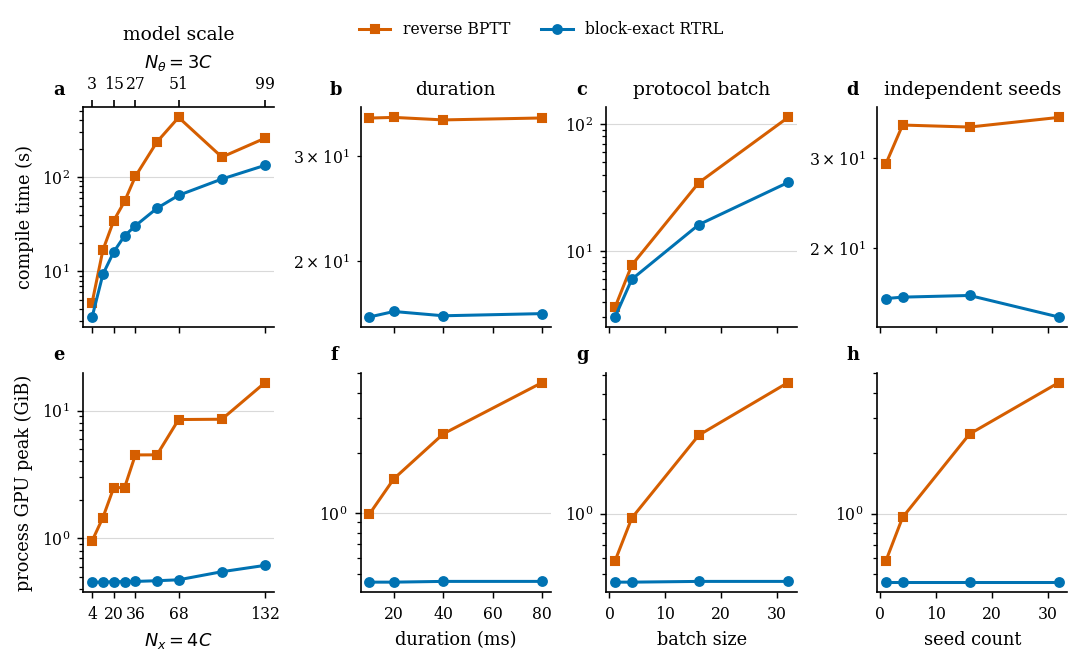

,method,GPU util baseline (%),GPU util range (%),memory-controller baseline (%),memory-controller range (%),power baseline (W),power range (W)
0,reverse BPTT,99.0,96–100,0.0,0–2,70.7,68–72
1,block-exact RTRL,100.0,98–100,0.0,0–16,84.6,70–143


,config_id,method,steady_median_seconds,compile_seconds,temporary_bytes,gpu_peak_steady_bytes,rtrl_carry_bytes,gpu_util_steady_median_percent,gpu_power_steady_median_watts,bptt_over_rtrl_time
20,c5_t40_b32_s32,bptt,1.207326,115.825754,5675864056,9355395072,NaN,100.0,69.750,4.170986
21,c5_t40_b32_s32,rtrl,0.289458,30.983970,7280824,490733568,3840000.0,100.0,105.920,4.170986
26,c5_t80_b32_s16,bptt,2.692842,113.503960,5675532536,9357492224,NaN,100.0,68.585,5.401794
27,c5_t80_b32_s16,rtrl,0.498509,34.718443,4620216,494927872,1920000.0,100.0,93.470,5.401794
32,c9_t40_b16_s32,bptt,1.482164,165.352801,5298102768,9118416896,NaN,99.0,69.750,2.866522
33,c9_t40_b16_s32,rtrl,0.517060,32.147939,13749176,492830720,6414336.0,100.0,101.230,2.866522
34,c9_t80_b32_s32,bptt,4.892512,435.058262,21418056304,35949379584,NaN,100.0,70.160,3.522049
35,c9_t80_b32_s32,rtrl,1.389109,56.681954,27239864,505413632,12386304.0,100.0,123.860,3.522049


largest corner c9_t80_b32_s32: BPTT 4.893s / 33.48 GiB; RTRL 1.389s / 0.47 GiB
saved:
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/figS2_system_diagnostics.pdf
  examples/experimental/optim_gradient_scaling/artifacts/rtrl_bptt_scaling/figures/figS2_system_diagnostics.png


In [18]:
fig, axes = plt.subplots(2, 4, figsize=(FULL_WIDTH_IN, 4.25), constrained_layout=True)
system_metrics = (
    ("compile_seconds", 1.0, "compile time (s)"),
    ("gpu_peak_steady_bytes", 2**30, "process GPU peak (GiB)"),
)
column_titles = ("model scale", "duration", "protocol batch", "independent seeds")
bottom_labels = (r"$N_x = 4C$", "duration (ms)", "batch size", "seed count")
for column, ((axis, _xlabel), title, bottom_label) in enumerate(zip(AXES, column_titles, bottom_labels)):
    selected = axis_slice(axis)
    for row_index, (metric, scale, ylabel) in enumerate(system_metrics):
        panel = axes[row_index, column]
        for method in ("bptt", "rtrl"):
            rows = selected[selected.method == method].sort_values(axis)
            panel.plot(axis_coordinates(rows, axis), rows[metric] / scale, color=COLORS[method], marker=MARKERS[method])
        style_panel(panel, log_y=True)
        if column == 0:
            panel.set_ylabel(ylabel)
        if row_index == 0:
            panel.set_title(title)
            panel.tick_params(labelbottom=False)
        else:
            panel.set_xlabel(bottom_label)
    if axis == "n_cv":
        add_model_size_axis(axes[0, column], selected, label=True)
        ticks = model_size_ticks(selected)
        axes[1, column].set_xticks(4 * ticks.n_cv, (4 * ticks.n_cv).astype(str))
add_panel_labels(axes)
fig.legend(handles=method_handles(), loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.02))
figure_s2_paths = save_figure(fig, "figS2_system_diagnostics")
plt.show()
display(
    system_summary.round({"GPU util baseline (%)": 1, "memory-controller baseline (%)": 1, "power baseline (W)": 1})
)
display(corners)
if len(largest) == 2:
    print(
        f"largest corner {largest_id}: BPTT {largest.loc['bptt', 'steady_median_seconds']:.3f}s / {largest.loc['bptt', 'gpu_peak_steady_bytes'] / 2**30:.2f} GiB; "
        f"RTRL {largest.loc['rtrl', 'steady_median_seconds']:.3f}s / {largest.loc['rtrl', 'gpu_peak_steady_bytes'] / 2**30:.2f} GiB"
    )
print("saved:", *(str(path) for path in figure_s2_paths), sep="\n  ")

## 结论边界

- Full suite 使用完整单轴点和四个交互角点；large-CV结果继续扩展同一CV单轴。
- seed block `vmap` 让 S 轴表示真正独立的 multistart throughput，而不是跨 seed 零块。
- 正常 gradient kernel 不含 diagnostics 或 Adam；两种方法都返回相同的逐步 losses 和命名总梯度。
- Large-CV测试到C33仍未耗尽80GB显存，但BPTT从C25开始出现明显运行时间拐点。
- Ordinary backsub降低BPTT temporary但在当前并行轴下更慢；RTRL几乎没有temporary收益且明显更慢。C17→C25拐点在ordinary模式仍存在。
- Supplementary Figure S4 的 controlled synthetic 最大四点 XLA-flop 指数为 `0.986/0.997/0.000/0.958`，XLA-temporary 指数为 `1.000/0.982/0.000/0.947`；二者均接近 `Nx/Nθ` 理论 `1/1/0/1`。
- 同一 synthetic 数据的 A100 wall-clock 最大四点指数为 `0.367/0.777/0.004/1.146`，说明有限尺寸 GPU 并行会压平或扭曲时间斜率，不能用负值或近零值直接否定算法阶数。
- Figure 4 的 full-HH `Nx` 轴最大四点 runtime 指数为 BPTT `1.718`、RTRL `1.167`，temporary 指数为 `1.087/0.972`；Leak-sharing `Nθ` 轴 temporary 指数为 `0.000/0.759`。HH sharing 改变 materialization topology，因此只解释为应用级响应。
- Mechanism factorial 已降级为 Supplementary Figure S3，只用于解释 channel mechanism / trainable subset 的 runtime 与 memory 消融。